In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

2025-05-17 19:04:53.180708: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-17 19:04:53.226507: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-17 19:04:53.911841: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Load by file name
R2502_2503 = pd.read_pickle("R2502_2503.pkl")
R2503_2502 = pd.read_pickle("R2503_2502.pkl")
R2503_2504 = pd.read_pickle("R2503_2504.pkl")
R2504_2503 = pd.read_pickle("R2504_2503.pkl")
R2502_2504 = pd.read_pickle("R2502_2504.pkl")
R2504_2502 = pd.read_pickle("R2504_2502.pkl")

F2504 = pd.read_pickle("2504.pkl")

In [3]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-B")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-B2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-B*DIFF-PRESS-15min.txt"):
    print("found:", p.name)

/home/seismic/AxialFetch/MJ03F-B → True (dir)
/home/seismic/AxialFetch/MJ03F-B/MJ03F-B2022DIFF-PRESS-15min.txt → True
found: MJ03F-B2023DIFF-PRESS-15min.txt
found: MJ03F-B2022DIFF-PRESS-15min.txt
found: MJ03F-B2021DIFF-PRESS-15min.txt
found: MJ03F-B2020DIFF-PRESS-15min.txt
found: MJ03F-B2019DIFF-PRESS-15min.txt
found: MJ03F-B2018DIFF-PRESS-15min.txt
found: MJ03F-B2017DIFF-PRESS-15min.txt
found: MJ03F-B2024DIFF-PRESS-15min.txt


Rows in df_pressure: 994


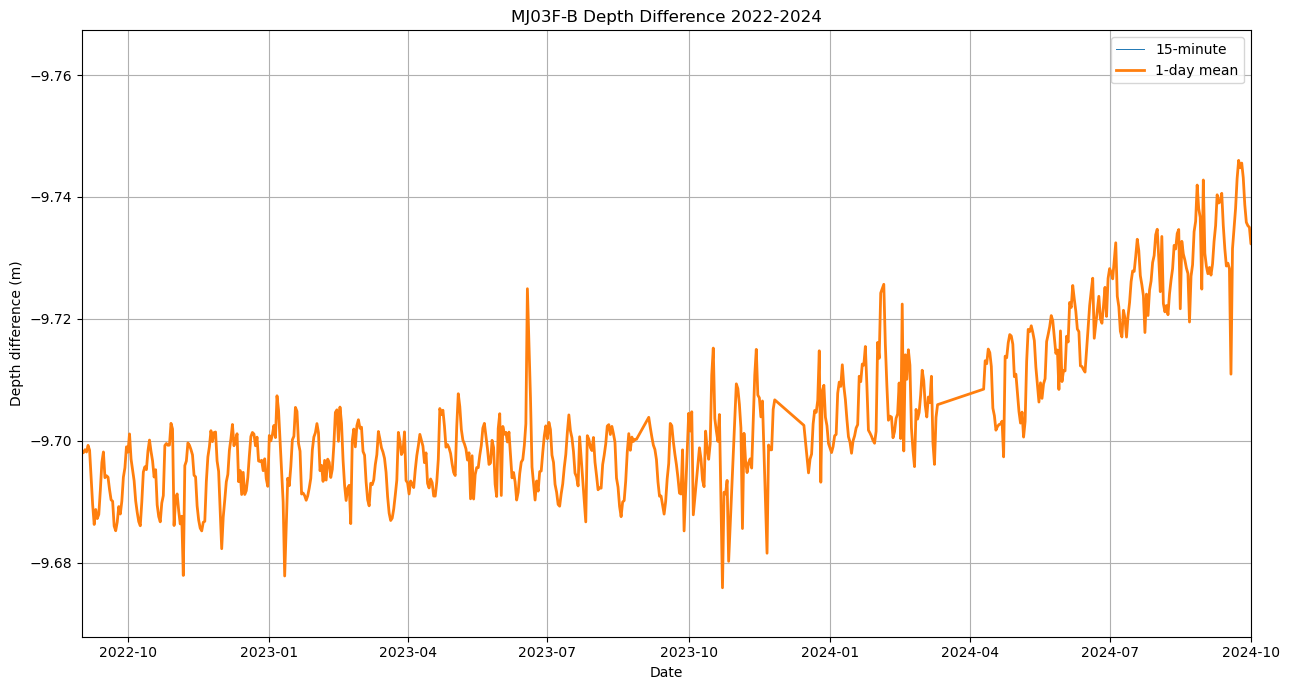

In [4]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-B")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
#plt.ylim(-14.55, -14.45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

del df_1day

Rows in df_pressure: 994


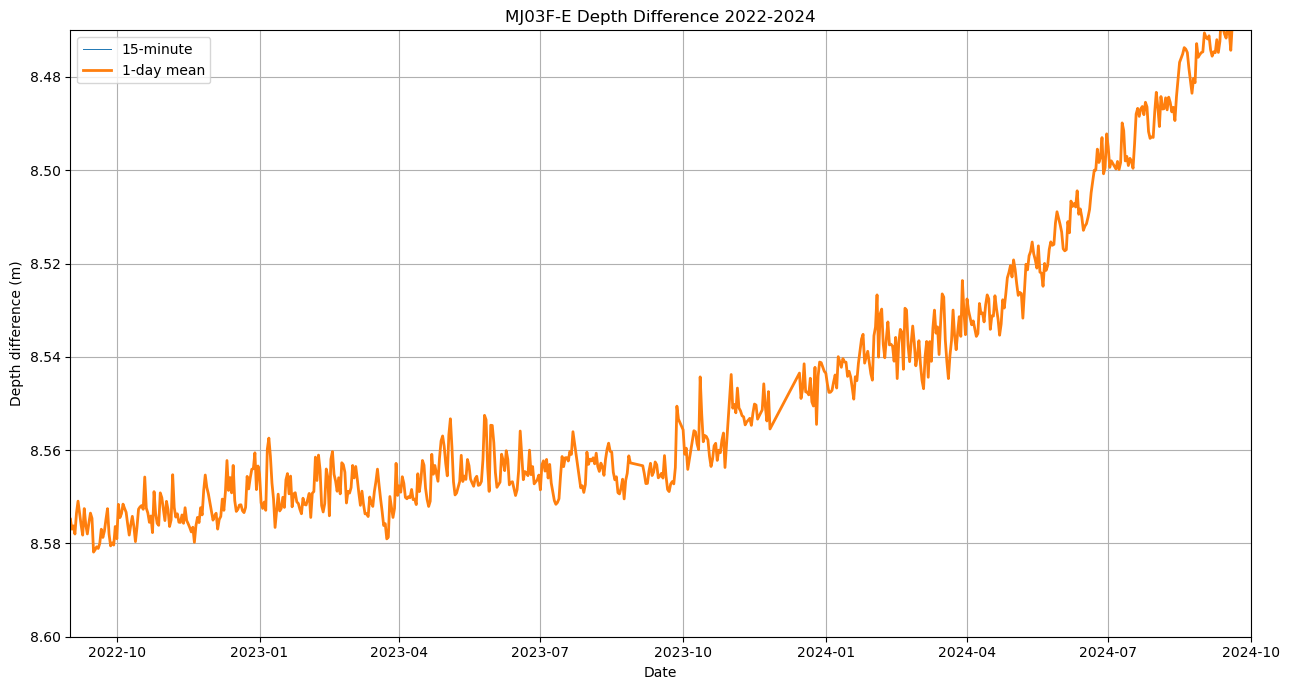

In [5]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure1 = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.47)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2503_2502, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
p1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

p2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

# distance opposite direction d2
d2 = to_series(R2502_2503, "Record Time", "Moving Average")
d3 = to_series(R2502_2504, "Record Time", "Moving Average")
d4 = to_series(R2504_2502, "Record Time", "Moving Average")
d5 = to_series(R2503_2504, "Record Time", "Moving Average")
d6 = to_series(R2504_2503, "Record Time", "Moving Average")

# corrected pressure p2
p3 = to_series(F2504, "DateTime", "Corrected Pressure (kPa)")

In [7]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)
df_var["p3"] = onto_master(p3, df_var.index)
df_var["d3"] = onto_master(d3, df_var.index)
df_var["d4"] = onto_master(d4, df_var.index)
df_var["d5"] = onto_master(d5, df_var.index)
df_var["d6"] = onto_master(d6, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "p3", "d1", "d2", "d3", "d4", "d5", "d6"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [8]:
import os
# -----------------------------------------------------------------------------
# 0) FORCE CPU PARALLELISM TO 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# Tell TensorFlow to use 48 threads
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)


In [24]:
import os
# -----------------------------------------------------------------------------
# USE 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# configure TensorFlow threading
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# -----------------------------------------------------------------------------
# 1) PREP DATA (assumes df_var in namespace)
# -----------------------------------------------------------------------------
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022,9,7,tz='UTC')].reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'], 'p2': df_var['p2'], 'p3': df_var['p3'],
    'r_WE': df_var['d1'], 'r_EW': df_var['d2'], 'r_EC': df_var['d3'],
    'r_CE': df_var['d4'], 'r_WC': df_var['d5'], 'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# time & season
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds()/86400.0
ω = 2*np.pi/365.25
df['sin1'] = np.sin(ω*df['t_days'])
df['cos1'] = np.cos(ω*df['t_days'])

# standardized pressures
p1_std = (df['p1']-df['p1'].mean())/df['p1'].std()
p2_std = (df['p2']-df['p2'].mean())/df['p2'].std()
sin_t, cos_t = df['sin1'].values, df['cos1'].values

# -----------------------------------------------------------------------------
# 2) LEAST-SQUARES BLOCK FITS
# -----------------------------------------------------------------------------
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE,*_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC,*_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin, r_EC_lin = A_CE@x_CE, A_CE@x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW,*_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC,*_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin, r_WC_lin = A_CW@x_CW, A_CW@x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW,*_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE,*_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin, r_WE_lin = A_EW@x_EW, A_EW@x_WE

R_lin    = np.column_stack([r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]).astype('float32')
R_obs    = df[Y_cols].values.astype('float32')
R_resid  = (R_obs - R_lin).astype('float32')

# -----------------------------------------------------------------------------
# 3) BUILD FEATURE MATRIX & ALIGN
# -----------------------------------------------------------------------------
df_feat = pd.DataFrame({
    'p1':df['p1'],'p2':df['p2'],'p3':df['p3'],
    't_days':df['t_days'],'sin1':df['sin1'],'cos1':df['cos1']
})
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)
for col, arr in zip(
    ['r_WE_lin','r_EW_lin','r_WC_lin','r_CW_lin','r_CE_lin','r_EC_lin'],
    [r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]
):
    df_feat[col] = arr

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

# aligned arrays
idx            = df_feat.index.values
X_raw          = df_feat.values.astype('float32')
R_resid_aligned= R_resid[idx]
R_lin_aligned  = R_lin[idx]
R_true_aligned = R_obs[idx]

# -----------------------------------------------------------------------------
# 4) SCALE & SPLIT LAST 70%
# -----------------------------------------------------------------------------
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_aligned)
Rs_s     = scaler_R.transform(R_resid_aligned)

N         = Xs.shape[0]
start     = int(0.30 * N)
X_train   = Xs[start:]
Rs_train  = Rs_s[start:]
# we evaluate on full Xs

# constants for un-scaling in loss
mean_R = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R= K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# indices for LS-features
feat_cols = df_feat.columns.tolist()
i_CE, i_EC = feat_cols.index('r_CE_lin'), feat_cols.index('r_EC_lin')
i_CW, i_WC = feat_cols.index('r_CW_lin'), feat_cols.index('r_WC_lin')
i_WE, i_EW = feat_cols.index('r_WE_lin'), feat_cols.index('r_EW_lin')

# -----------------------------------------------------------------------------
# 5) HYPERPARAMETER GRID SEARCH
# -----------------------------------------------------------------------------
param_grid = {
    'w_mse':   [0.1, 1, 5, 10],
    'w_sym':   [0.01, 0.1, 0.5],
    'w_clo':   [0.01, 0.1, 0.5],
    'w_hinge':[1, 5, 10, 20],
}
results = []

for w_mse, w_sym, w_clo, w_hinge in product(
    param_grid['w_mse'], param_grid['w_sym'],
    param_grid['w_clo'], param_grid['w_hinge']
):
    tf.keras.backend.clear_session()
    inp = layers.Input(shape=(Xs.shape[1],))
    shared = layers.Dense(64, activation='relu')(inp)
    shared = layers.Dense(64, activation='relu')(shared)

    # gather LS features for each head
    east = layers.Lambda(lambda x: tf.gather(x, [i_CE, i_EC], axis=1))(inp)
    west = layers.Lambda(lambda x: tf.gather(x, [i_CW, i_WC], axis=1))(inp)
    mid  = layers.Lambda(lambda x: tf.gather(x, [i_WE, i_EW], axis=1))(inp)

    def head_block(xf):
        xh = layers.Concatenate()([shared, xf])
        xh = layers.Dense(32, activation='relu')(xh)
        return layers.Dense(2)(xh)

    r_CE_p, r_EC_p = tf.split(head_block(east), 2, axis=1)
    r_CW_p, r_WC_p = tf.split(head_block(west), 2, axis=1)
    r_WE_p, r_EW_p = tf.split(head_block(mid), 2, axis=1)

    resid_out = layers.Concatenate()([
        r_WE_p, r_EW_p, r_WC_p, r_CW_p, r_CE_p, r_EC_p
    ])
    model = Model(inp, resid_out)

    def loss_fn(r_true_s, r_pred_s):
        r_true_m = r_true_s * scale_R + mean_R
        r_pred_m = r_pred_s * scale_R + mean_R
        Lm = K.mean(K.square(r_true_s - r_pred_s))
        CE, EC = r_pred_s[:,4], r_pred_s[:,5]
        CW, WC = r_pred_s[:,3], r_pred_s[:,2]
        Ls = K.mean(K.square(CE-EC) + K.square(CW-WC))
        dCE = CE[1:] - CE[:-1]; dCW = CW[1:] - CW[:-1]
        dEW = r_pred_s[1:,1] - r_pred_s[:-1,1]
        Lc = K.mean(K.square(dCE + dCW - dEW))
        delta = K.square(r_true_m - r_pred_m) - K.square(r_true_m)
        Lh = K.mean(K.maximum(delta, 0.0))
        return w_mse*Lm + w_sym*Ls + w_clo*Lc + w_hinge*Lh

    model.compile(optimizer='adam', loss=loss_fn)
    es = callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    model.fit(X_train, Rs_train, epochs=200, batch_size=len(X_train),
              callbacks=[es], verbose=0)

    # full-series prediction
    Rs_pred_s    = model.predict(Xs)
    Rs_pred      = scaler_R.inverse_transform(Rs_pred_s)
    R_pred_full  = R_lin_aligned + Rs_pred

    r2s = [r2_score(R_true_aligned[:,i], R_pred_full[:,i]) for i in range(6)]
    results.append({
        'w_mse': w_mse, 'w_sym': w_sym,
        'w_clo': w_clo, 'w_hinge': w_hinge,
        'mean_val_R2': np.mean(r2s),
        **{f'R2_{Y_cols[i]}': r2s[i] for i in range(6)}
    })

# display top 5
df_res = pd.DataFrame(results).sort_values('mean_val_R2', ascending=False)
print("Top 5 hyperparameter sets by mean validation R²:")
print(df_res.head(5))


136/136 [==============================] - 0s 872us/step
Top 5 hyperparameter sets by mean validation R²:
     w_mse  w_sym  w_clo  w_hinge  mean_val_R2   R2_r_WE   R2_r_EW   R2_r_WC  \
133   10.0   0.50   0.01        5     0.860820  0.945840  0.895953  0.757214   
115   10.0   0.01   0.10       20     0.840064  0.902080  0.888231  0.740401   
91     5.0   0.10   0.10       20     0.835978  0.880806  0.856953  0.704967   
87     5.0   0.10   0.01       20     0.833838  0.885330  0.839287  0.690086   
111   10.0   0.01   0.01       20     0.833038  0.923860  0.869820  0.696836   

      R2_r_CW   R2_r_CE   R2_r_EC  
133  0.670876  0.958371  0.936663  
115  0.609211  0.949658  0.950801  
91   0.701763  0.937821  0.933560  
87   0.690567  0.954515  0.943239  
111  0.621572  0.941360  0.944778  


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# =============================================================================
# THREE-HEAD LS+PINN HYBRID WITH STRICT HINGE LOSS
#    – TRAIN ON LAST 70% – EVALUATE FULL SERIES (CORRECTED)
# =============================================================================

# 0) LOAD & FILTER DATA
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022,9,7,tz='UTC')].reset_index(drop=True)
df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'], 'p2': df_var['p2'], 'p3': df_var['p3'],
    'r_WE': df_var['d1'], 'r_EW': df_var['d2'], 'r_EC': df_var['d3'],
    'r_CE': df_var['d4'], 'r_WC': df_var['d5'], 'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) COMPUTE TIME & SEASONAL + LS FITS
t0     = df['time'].min()
df['t_days'] = (df['time']-t0).dt.total_seconds()/86400.0
ω      = 2*np.pi/365.25
df['sin1'] = np.sin(ω*df['t_days'])
df['cos1'] = np.cos(ω*df['t_days'])
p1_std = (df['p1']-df['p1'].mean())/df['p1'].std()
p2_std = (df['p2']-df['p2'].mean())/df['p2'].std()

sin_t, cos_t = df['sin1'].values, df['cos1'].values

# LS blocks
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE,*_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC,*_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin, r_EC_lin = A_CE@x_CE, A_CE@x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW,*_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC,*_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin, r_WC_lin = A_CW@x_CW, A_CW@x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW,*_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE,*_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin, r_WE_lin = A_EW@x_EW, A_EW@x_WE

R_lin = np.column_stack([r_WE_lin,r_EW_lin,r_WC_lin,r_CW_lin,r_CE_lin,r_EC_lin]).astype('float32')
R_obs = df[Y_cols].values.astype('float32')
R_resid = R_obs - R_lin

# 2) BUILD FEATURE MATRIX + LS inputs
df_feat = pd.DataFrame({
    'p1':df['p1'],'p2':df['p2'],'p3':df['p3'],
    't_days':df['t_days'],'sin1':df['sin1'],'cos1':df['cos1']
})
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)
for col, arr in zip(
    ['r_WE_lin','r_EW_lin','r_WC_lin','r_CW_lin','r_CE_lin','r_EC_lin'],
    [r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]
):
    df_feat[col] = arr
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

idx = df_feat.index.values
X_raw         = df_feat.values.astype('float32')
R_resid_true  = R_resid[idx]
R_lin_full    = R_lin[idx]
R_true_full   = R_obs[idx]
times_full    = df['time'].values[idx]

# 3) SCALE
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_true)
Rs_scaled= scaler_R.transform(R_resid_true)
mean_R   = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R  = K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# 4) TRAIN ON LAST 70%
N = Xs.shape[0]
start = int(0.30*N)
X_train = Xs[start:]
R_train = Rs_scaled[start:]

# 5) DEFINE 3-HEAD PINN
inp = layers.Input(shape=(Xs.shape[1],))
shared = layers.Dense(64,activation='relu')(inp)
shared = layers.Dense(64,activation='relu')(shared)

cols = df_feat.columns.tolist()
def gather(idxs):
    return layers.Lambda(lambda x: tf.gather(x, idxs, axis=1))(inp)

east = gather([cols.index('r_CE_lin'), cols.index('r_EC_lin')])
west = gather([cols.index('r_CW_lin'), cols.index('r_WC_lin')])
mid  = gather([cols.index('r_WE_lin'), cols.index('r_EW_lin')])

def head_block(x_feat):
    xh = layers.Concatenate()([shared, x_feat])
    xh = layers.Dense(32,activation='relu')(xh)
    return layers.Dense(2)(xh)

r_CE_p, r_EC_p = tf.split(head_block(east),2,axis=1)
r_CW_p, r_WC_p = tf.split(head_block(west),2,axis=1)
r_WE_p, r_EW_p = tf.split(head_block(mid),2,axis=1)
resid_out = layers.Concatenate()([r_WE_p, r_EW_p, r_WC_p, r_CW_p, r_CE_p, r_EC_p])

model = Model(inp, resid_out)

# 6) STRICT HINGE LOSS
def loss_fn(r_true_s, r_pred_s):
    r_true_m = r_true_s*scale_R + mean_R
    r_pred_m = r_pred_s*scale_R + mean_R
    Lm = K.mean(K.square(r_true_s - r_pred_s))
    CE, EC = r_pred_s[:,4], r_pred_s[:,5]
    CW, WC = r_pred_s[:,3], r_pred_s[:,2]
    Ls = K.mean(K.square(CE-EC)+K.square(CW-WC))
    dCE = CE[1:]-CE[:-1]; dCW = CW[1:]-CW[:-1]
    dEW = r_pred_s[1:,1]-r_pred_s[:-1,1]
    Lc = K.mean(K.square(dCE + dCW - dEW))
    delta = K.square(r_true_m - r_pred_m) - K.square(r_true_m)
    Lh = K.mean(K.maximum(delta,0.0))
    return 1.0*Lm + 0.1*Ls + 0.1*Lc + 10.0*Lh

model.compile(optimizer='adam', loss=loss_fn)

# 7) TRAIN
es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)
model.fit(X_train, R_train, epochs=300, batch_size=len(X_train), callbacks=[es], verbose=1)

# 8) PREDICT & RECONSTRUCT FULL
Rs_pred_s   = model.predict(Xs)
Rs_pred     = scaler_R.inverse_transform(Rs_pred_s)
R_pred_full = R_lin_full + Rs_pred

# 9) EVALUATE
print("LS-only metrics:")
for i,name in enumerate(Y_cols):
    print(f"{name}: R²={r2_score(R_true_full[:,i], R_lin_full[:,i]):.3f}, RMSE={mean_squared_error(R_true_full[:,i], R_lin_full[:,i], squared=False):.3f}")
print("\nHybrid 3-head PINN metrics:")
for i,name in enumerate(Y_cols):
    print(f"{name}: R²={r2_score(R_true_full[:,i], R_pred_full[:,i]):.3f}, RMSE={mean_squared_error(R_true_full[:,i], R_pred_full[:,i], squared=False):.3f}")



Epoch 1/300
1/1 [==============================] - 1s 1s/step - loss: 6.5186
Epoch 2/300
1/1 [==============================] - 0s 8ms/step - loss: 5.3169
Epoch 3/300
1/1 [==============================] - 0s 8ms/step - loss: 4.3190
Epoch 4/300
1/1 [==============================] - 0s 7ms/step - loss: 3.5125
Epoch 5/300
1/1 [==============================] - 0s 7ms/step - loss: 2.8583
Epoch 6/300
1/1 [==============================] - 0s 7ms/step - loss: 2.3577
Epoch 7/300
1/1 [==============================] - 0s 7ms/step - loss: 2.0354
Epoch 8/300
1/1 [==============================] - 0s 8ms/step - loss: 1.8574
Epoch 9/300
1/1 [==============================] - 0s 7ms/step - loss: 1.7568
Epoch 10/300
1/1 [==============================] - 0s 7ms/step - loss: 1.6785
Epoch 11/300
1/1 [==============================] - 0s 7ms/step - loss: 1.6114
Epoch 12/300
1/1 [==============================] - 0s 7ms/step - loss: 1.5397
Epoch 13/300
1/1 [==============================] - 0s 7ms/ste

1/1 [==============================] - 0s 7ms/step - loss: 0.5827
Epoch 207/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5807
Epoch 208/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5782
Epoch 209/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5765
Epoch 210/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5755
Epoch 211/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5718
Epoch 212/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5701
Epoch 213/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5684
Epoch 214/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5662
Epoch 215/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5642
Epoch 216/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5616
Epoch 217/300
1/1 [==============================] - 0s 7ms/step - loss: 0.5601
Epoch 218/300
1/1 [==============================] - 0

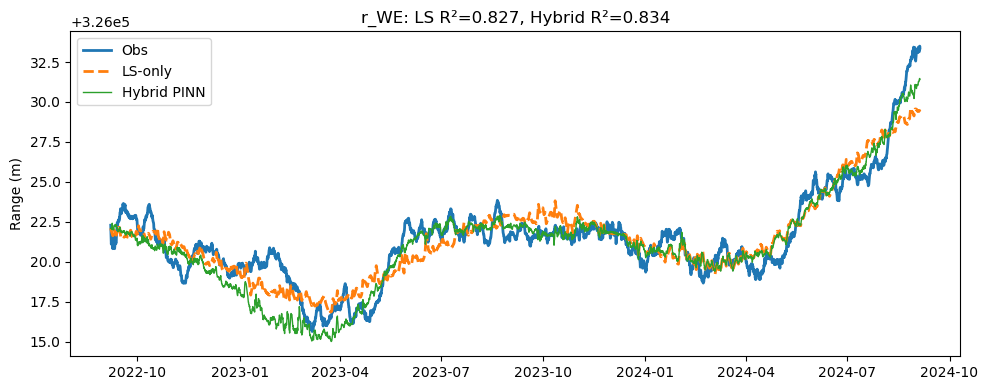

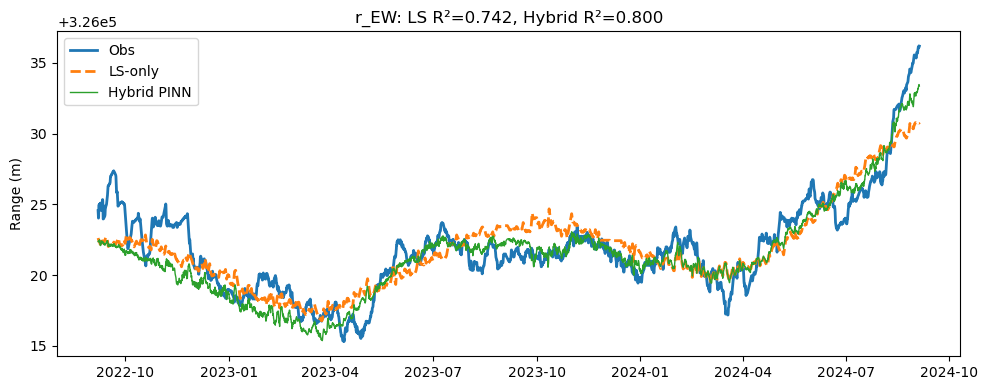

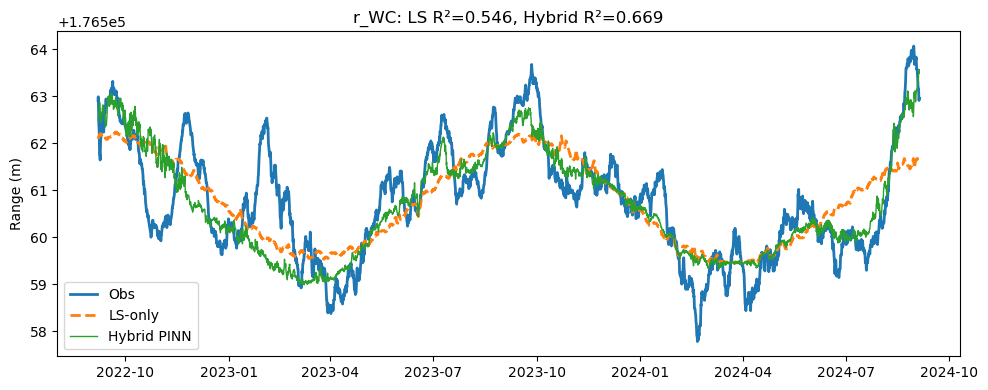

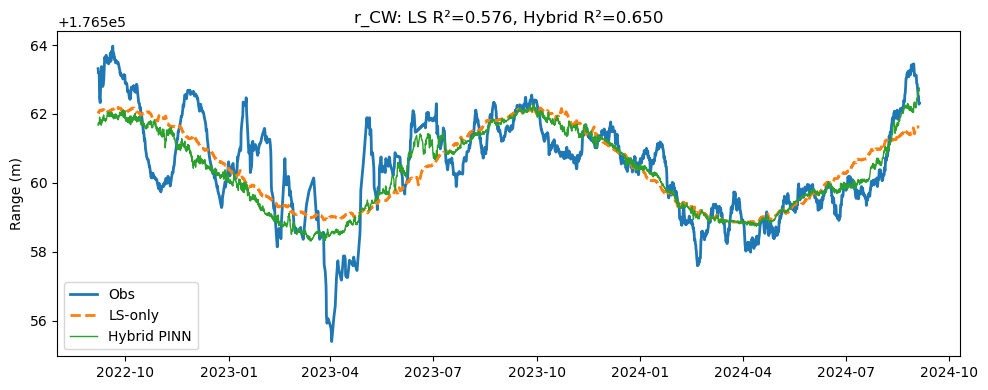

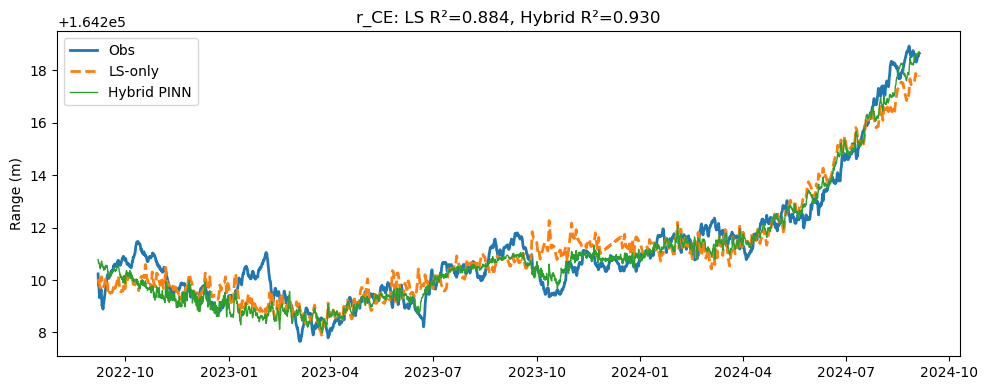

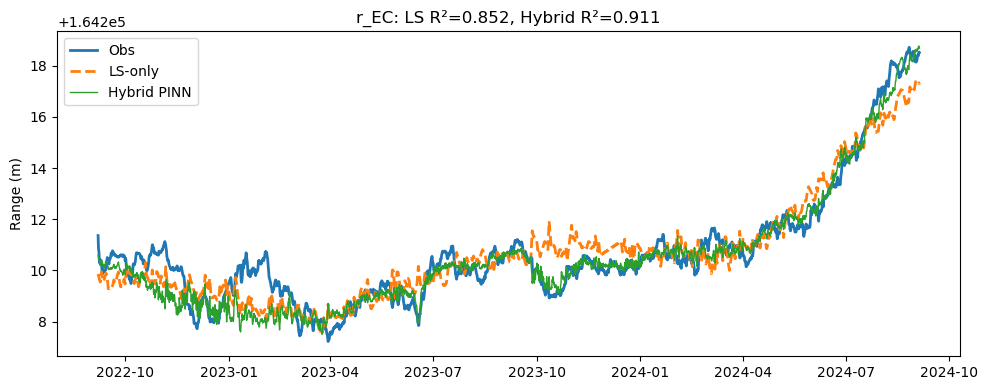

In [21]:
# 10) PLOT
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(times_full, R_true_full[:,i], label='Obs', lw=2)
    ax.plot(times_full, R_lin_full[:,i],  label='LS-only', ls='--', lw=2)
    ax.plot(times_full, R_pred_full[:,i], label='Hybrid PINN', lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(R_true_full[:,i], R_lin_full[:,i]):.3f}, Hybrid R²={r2_score(R_true_full[:,i], R_pred_full[:,i]):.3f}")
    ax.legend(); ax.set_ylabel("Range (m)")
    plt.show()


In [25]:
import os
# -----------------------------------------------------------------------------
# FORCE CPU PARALLELISM TO 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# configure TensorFlow threading
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# =============================================================================
# FINAL TRAINING WITH BEST HYPERPARAMETERS (LAST 70% TRAIN, EVALUATE FULL SERIES)
# =============================================================================

# 0) LOAD & FILTER DATA
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022,9,7,tz='UTC')].reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],  'p2': df_var['p2'],  'p3': df_var['p3'],
    'r_WE': df_var['d1'],  'r_EW': df_var['d2'],  'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],  'r_WC': df_var['d5'],  'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASONAL FEATURES + STANDARDIZED PRESSURES
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2 * np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()
sin_t, cos_t = df['sin1'].values, df['cos1'].values

# 2) LEAST-SQUARES BLOCKS
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE,*_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC,*_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin, r_EC_lin = A_CE @ x_CE, A_CE @ x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW,*_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC,*_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin, r_WC_lin = A_CW @ x_CW, A_CW @ x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW,*_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE,*_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin, r_WE_lin = A_EW @ x_EW, A_EW @ x_WE

R_lin = np.column_stack([
    r_WE_lin, r_EW_lin, r_WC_lin,
    r_CW_lin, r_CE_lin, r_EC_lin
]).astype('float32')
R_obs   = df[Y_cols].values.astype('float32')
R_resid = (R_obs - R_lin).astype('float32')

# 3) FEATURE MATRIX + LAGS + LS FEATURES
df_feat = df[['p1','p2','p3','t_days','sin1','cos1']].copy()
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)

ls_cols = ['r_WE_lin','r_EW_lin','r_WC_lin','r_CW_lin','r_CE_lin','r_EC_lin']
ls_vals = [r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]
for col, arr in zip(ls_cols, ls_vals):
    df_feat[col] = arr

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

idx = df_feat.index.values
X_raw         = df_feat.values.astype('float32')
R_resid_true  = R_resid[idx]
R_lin_aligned = R_lin[idx]
R_true_aligned= R_obs[idx]
times_aligned = df['time'].values[idx]

# 4) SCALE & TRAIN/VAL SPLIT (last 70% train)
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_true)
Rs_s     = scaler_R.transform(R_resid_true)

N = Xs.shape[0]
start = int(0.30 * N)
X_train   = Xs[start:]
Rs_train  = Rs_s[start:]

mean_R = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R= K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# indices for LS features
feat_cols = df_feat.columns.tolist()
i_CE, i_EC = feat_cols.index('r_CE_lin'), feat_cols.index('r_EC_lin')
i_CW, i_WC = feat_cols.index('r_CW_lin'), feat_cols.index('r_WC_lin')
i_WE, i_EW = feat_cols.index('r_WE_lin'), feat_cols.index('r_EW_lin')

# 5) BUILD & TRAIN FINAL 3-HEAD PINN
w_mse, w_sym, w_clo, w_hinge = 10.0, 0.5, 0.01, 5.0

inp = layers.Input(shape=(Xs.shape[1],))
shared = layers.Dense(64,activation='relu')(inp)
shared = layers.Dense(64,activation='relu')(shared)

east = layers.Lambda(lambda x: tf.gather(x,[i_CE,i_EC],axis=1))(inp)
west = layers.Lambda(lambda x: tf.gather(x,[i_CW,i_WC],axis=1))(inp)
mid  = layers.Lambda(lambda x: tf.gather(x,[i_WE,i_EW],axis=1))(inp)

def head_block(xf):
    xh = layers.Concatenate()([shared, xf])
    xh = layers.Dense(32,activation='relu')(xh)
    return layers.Dense(2)(xh)

r_CE_p, r_EC_p = tf.split(head_block(east),2,axis=1)
r_CW_p, r_WC_p = tf.split(head_block(west),2,axis=1)
r_WE_p, r_EW_p = tf.split(head_block(mid),2,axis=1)

resid_out = layers.Concatenate()([
    r_WE_p, r_EW_p, r_WC_p, r_CW_p, r_CE_p, r_EC_p
])
model = Model(inp, resid_out)

def loss_fn(r_true_s, r_pred_s):
    r_true_m = r_true_s*scale_R + mean_R
    r_pred_m = r_pred_s*scale_R + mean_R
    Lm   = K.mean(K.square(r_true_s - r_pred_s))
    CE,EC= r_pred_s[:,4], r_pred_s[:,5]
    CW,WC= r_pred_s[:,3], r_pred_s[:,2]
    Ls   = K.mean(K.square(CE-EC)+K.square(CW-WC))
    dCE  = CE[1:]-CE[:-1]; dCW= CW[1:]-CW[:-1]
    dEW  = r_pred_s[1:,1]-r_pred_s[:-1,1]
    Lc   = K.mean(K.square(dCE + dCW - dEW))
    delta= K.square(r_true_m-r_pred_m)-K.square(r_true_m)
    Lh   = K.mean(K.maximum(delta,0.0))
    return w_mse*Lm + w_sym*Ls + w_clo*Lc + w_hinge*Lh

model.compile(optimizer='adam', loss=loss_fn)
es = callbacks.EarlyStopping(monitor='loss',patience=30,restore_best_weights=True)
model.fit(X_train, Rs_train, epochs=300, batch_size=len(X_train), callbacks=[es], verbose=1)

# 6) PREDICT & RECONSTRUCT FULL SERIES
Rs_pred_s   = model.predict(Xs)
Rs_pred     = scaler_R.inverse_transform(Rs_pred_s)
R_pred_full = R_lin_aligned + Rs_pred

# 7) EVALUATE FINAL METRICS
print("LS-only metrics:")
for i,name in enumerate(Y_cols):
    r2_lin = r2_score(R_true_aligned[:,i], R_lin_aligned[:,i])
    rmse_lin = mean_squared_error(R_true_aligned[:,i], R_lin_aligned[:,i], squared=False)
    print(f"{name}: R²={r2_lin:.3f}, RMSE={rmse_lin:.3f} m")

print("\nHybrid PINN (final) metrics:")
for i,name in enumerate(Y_cols):
    r2_h = r2_score(R_true_aligned[:,i], R_pred_full[:,i])
    rmse_h = mean_squared_error(R_true_aligned[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2_h:.3f}, RMSE={rmse_h:.3f} m")




Epoch 1/300
1/1 [==============================] - 1s 1s/step - loss: 14.2706
Epoch 2/300
1/1 [==============================] - 0s 8ms/step - loss: 12.6822
Epoch 3/300
1/1 [==============================] - 0s 8ms/step - loss: 11.5621
Epoch 4/300
1/1 [==============================] - 0s 7ms/step - loss: 10.8113
Epoch 5/300
1/1 [==============================] - 0s 8ms/step - loss: 10.3057
Epoch 6/300
1/1 [==============================] - 0s 7ms/step - loss: 9.9440
Epoch 7/300
1/1 [==============================] - 0s 7ms/step - loss: 9.6701
Epoch 8/300
1/1 [==============================] - 0s 7ms/step - loss: 9.5044
Epoch 9/300
1/1 [==============================] - 0s 8ms/step - loss: 9.3799
Epoch 10/300
1/1 [==============================] - 0s 8ms/step - loss: 9.2526
Epoch 11/300
1/1 [==============================] - 0s 7ms/step - loss: 9.1220
Epoch 12/300
1/1 [==============================] - 0s 7ms/step - loss: 8.9927
Epoch 13/300
1/1 [==============================] - 0s 7m

1/1 [==============================] - 0s 7ms/step - loss: 1.4465
Epoch 207/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4388
Epoch 208/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4306
Epoch 209/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4231
Epoch 210/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4159
Epoch 211/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4088
Epoch 212/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4026
Epoch 213/300
1/1 [==============================] - 0s 7ms/step - loss: 1.3945
Epoch 214/300
1/1 [==============================] - 0s 7ms/step - loss: 1.3862
Epoch 215/300
1/1 [==============================] - 0s 7ms/step - loss: 1.3786
Epoch 216/300
1/1 [==============================] - 0s 7ms/step - loss: 1.3728
Epoch 217/300
1/1 [==============================] - 0s 7ms/step - loss: 1.3661
Epoch 218/300
1/1 [==============================] - 0

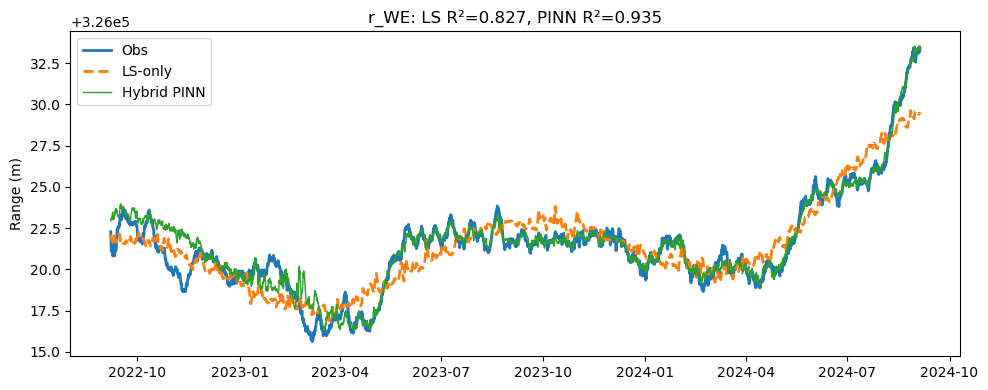

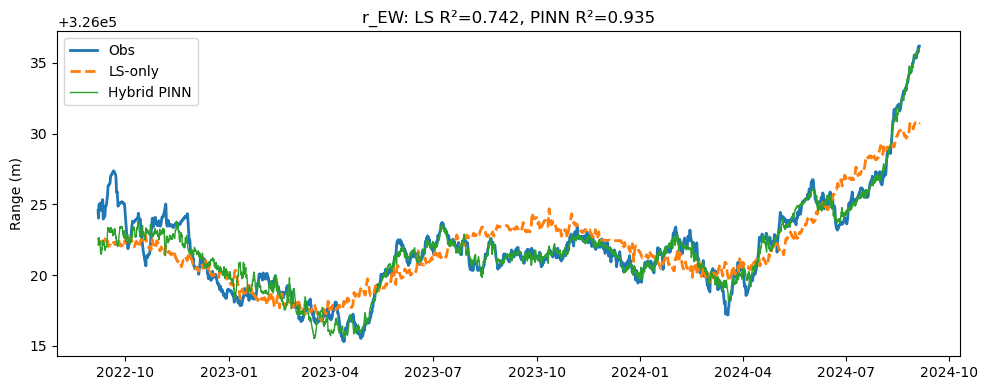

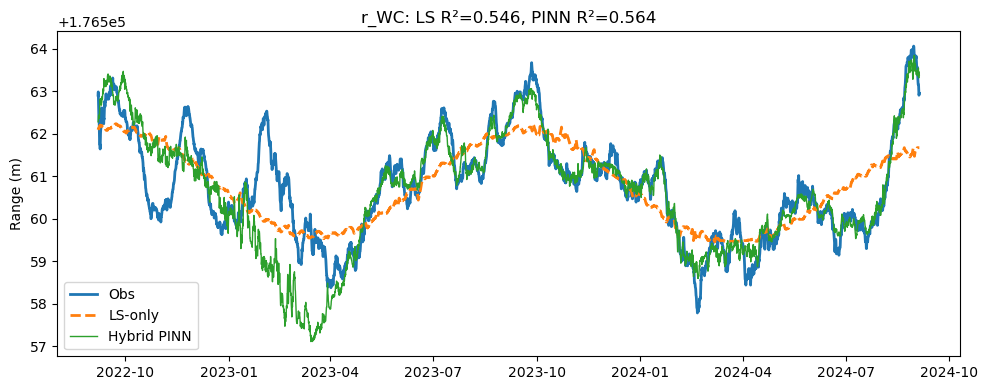

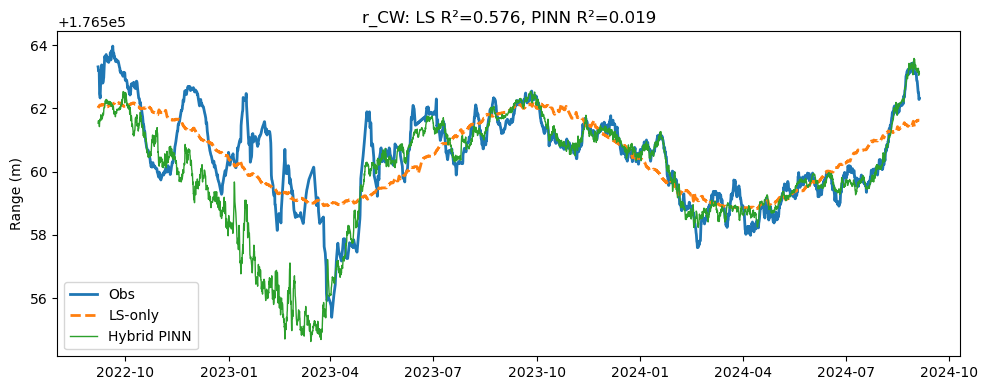

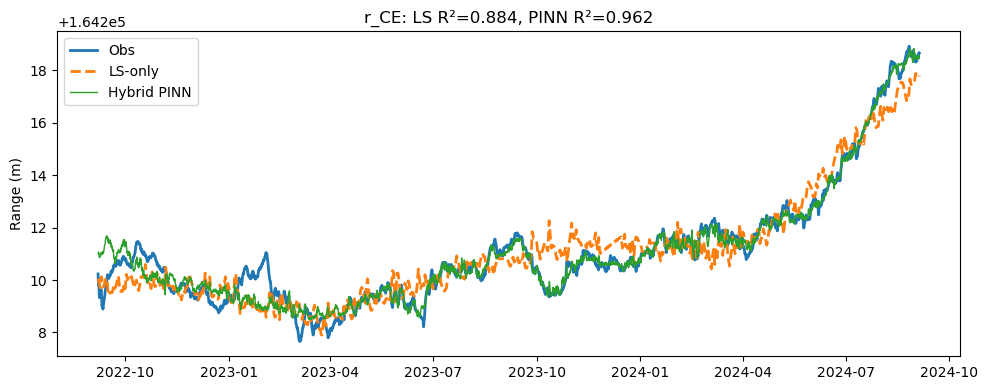

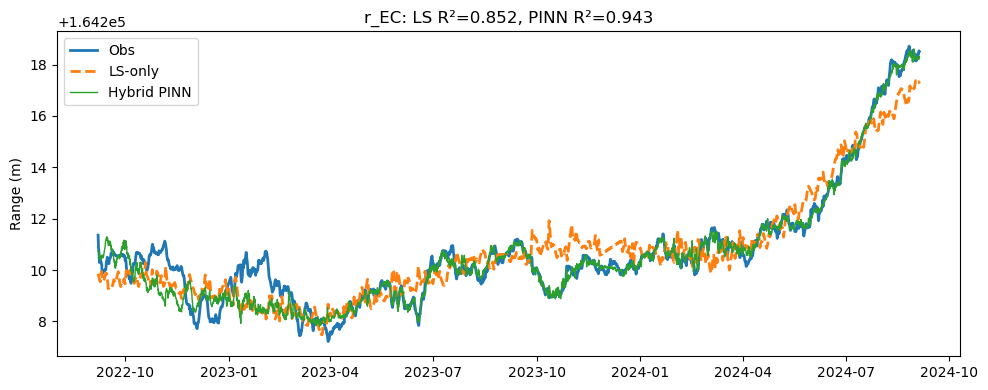

In [26]:
# 8) PLOT RESULTS
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(times_aligned,  R_true_aligned[:,i], label='Obs', lw=2)
    ax.plot(times_aligned,  R_lin_aligned[:,i],  label='LS-only', ls='--', lw=2)
    ax.plot(times_aligned,  R_pred_full[:,i],   label='Hybrid PINN', lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(R_true_aligned[:,i], R_lin_aligned[:,i]):.3f}, "
                 f"PINN R²={r2_score(R_true_aligned[:,i], R_pred_full[:,i]):.3f}")
    ax.legend(); ax.set_ylabel("Range (m)")
    plt.show()


In [27]:
import os
# -----------------------------------------------------------------------------
# FORCE CPU PARALLELISM TO 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# configure TensorFlow threading
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# =============================================================================
# FINAL TRAINING WITH ABSOLUTE-ERROR HINGE LOSS
# ‑ TRAIN ON LAST 70% – EVALUATE FULL SERIES
# =============================================================================

# 0) LOAD & FILTER
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022,9,7,tz='UTC')].reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],  'p2': df_var['p2'],  'p3': df_var['p3'],
    'r_WE': df_var['d1'],  'r_EW': df_var['d2'],  'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],  'r_WC': df_var['d5'],  'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASON + STANDARDIZED PRESSURES
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2 * np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()
sin_t, cos_t = df['sin1'].values, df['cos1'].values

# 2) LEAST-SQUARES BLOCKS
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE,*_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC,*_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin, r_EC_lin = A_CE @ x_CE, A_CE @ x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW,*_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC,*_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin, r_WC_lin = A_CW @ x_CW, A_CW @ x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW,*_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE,*_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin, r_WE_lin = A_EW @ x_EW, A_EW @ x_WE

R_lin        = np.column_stack([r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]).astype('float32')
R_obs        = df[Y_cols].values.astype('float32')
R_resid_full = (R_obs - R_lin).astype('float32')

# 3) FEATURE MATRIX + LAGS + LS FEATURES
df_feat = pd.DataFrame({
    'p1': df['p1'], 'p2': df['p2'], 'p3': df['p3'],
    't_days': df['t_days'], 'sin1': df['sin1'], 'cos1': df['cos1']
})
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)
for col, arr in zip(['r_WE_lin','r_EW_lin','r_WC_lin','r_CW_lin','r_CE_lin','r_EC_lin'],
                    [r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]):
    df_feat[col] = arr

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

idx            = df_feat.index.values
X_raw          = df_feat.values.astype('float32')
R_resid_aligned = R_resid_full[idx]
R_lin_aligned  = R_lin[idx]
R_true_aligned = R_obs[idx]
times_aligned  = df['time'].values[idx]

# 4) SCALE & SPLIT LAST 70%
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_aligned)
Rs_s     = scaler_R.transform(R_resid_aligned)

N       = Xs.shape[0]
start   = int(0.30 * N)
X_train = Xs[start:]
Rs_train= Rs_s[start:]

# constants for un-scaling
mean_R  = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R = K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# indices for LS features per head
feat_cols = df_feat.columns.tolist()
i_CE, i_EC = feat_cols.index('r_CE_lin'), feat_cols.index('r_EC_lin')
i_CW, i_WC = feat_cols.index('r_CW_lin'), feat_cols.index('r_WC_lin')
i_WE, i_EW = feat_cols.index('r_WE_lin'), feat_cols.index('r_EW_lin')

# 5) BUILD 3-HEAD PINN RESIDUAL MODEL
w_mse, w_sym, w_clo, w_hinge = 10.0, 0.5, 0.01, 5.0

inp    = layers.Input(shape=(Xs.shape[1],))
shared = layers.Dense(64, activation='relu')(inp)
shared = layers.Dense(64, activation='relu')(shared)

east = layers.Lambda(lambda x: tf.gather(x, [i_CE, i_EC], axis=1))(inp)
west = layers.Lambda(lambda x: tf.gather(x, [i_CW, i_WC], axis=1))(inp)
mid  = layers.Lambda(lambda x: tf.gather(x, [i_WE, i_EW], axis=1))(inp)

def head_block(xf):
    xh = layers.Concatenate()([shared, xf])
    xh = layers.Dense(32, activation='relu')(xh)
    return layers.Dense(2)(xh)

r_CE_p, r_EC_p = tf.split(head_block(east), 2, axis=1)
r_CW_p, r_WC_p = tf.split(head_block(west), 2, axis=1)
r_WE_p, r_EW_p = tf.split(head_block(mid), 2, axis=1)

resid_out = layers.Concatenate()([
    r_WE_p, r_EW_p,
    r_WC_p, r_CW_p,
    r_CE_p, r_EC_p
])
model = Model(inp, resid_out)

# 6) LOSS WITH ABSOLUTE-ERROR HINGE
def loss_fn(r_true_s, r_pred_s):
    # back to meter-scale errors
    e_ls     = r_true_s * scale_R + mean_R
    pred_res = r_pred_s * scale_R + mean_R
    e_hybrid = e_ls - pred_res

    # MSE on scaled residuals
    L_mse  = K.mean(K.square(r_true_s - r_pred_s))
    # symmetry
    CE, EC = r_pred_s[:,4], r_pred_s[:,5]
    CW, WC = r_pred_s[:,3], r_pred_s[:,2]
    L_sym  = K.mean(K.square(CE - EC) + K.square(CW - WC))
    # derivative closure
    dCE = CE[1:] - CE[:-1]; dCW = CW[1:] - CW[:-1]
    dEW = r_pred_s[1:,1] - r_pred_s[:-1,1]
    L_clo = K.mean(K.square(dCE + dCW - dEW))

    # absolute-error hinge
    delta = K.abs(e_hybrid) - K.abs(e_ls)
    L_hinge = K.mean(K.maximum(delta, 0.0))

    return (w_mse * L_mse
          + w_sym * L_sym
          + w_clo * L_clo
          + w_hinge * L_hinge)

model.compile(optimizer='adam', loss=loss_fn)
es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)

# 7) TRAIN ON LAST 70%
model.fit(X_train, Rs_train, epochs=300, batch_size=len(X_train),
          callbacks=[es], verbose=1)

# 8) PREDICT & RECONSTRUCT FULL SERIES
Rs_pred_s   = model.predict(Xs)
Rs_pred     = scaler_R.inverse_transform(Rs_pred_s)
R_pred_full = R_lin_aligned + Rs_pred

# 9) EVALUATE & PRINT METRICS
print("LS-only metrics:")
for i, name in enumerate(Y_cols):
    r2_lin  = r2_score(R_true_aligned[:,i], R_lin_aligned[:,i])
    rmse_lin= mean_squared_error(R_true_aligned[:,i], R_lin_aligned[:,i], squared=False)
    print(f"{name}: R²={r2_lin:.3f}, RMSE={rmse_lin:.3f} m")

print("\nHybrid PINN (absolute-hinge) metrics:")
for i, name in enumerate(Y_cols):
    r2_h   = r2_score(R_true_aligned[:,i], R_pred_full[:,i])
    rmse_h = mean_squared_error(R_true_aligned[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2_h:.3f}, RMSE={rmse_h:.3f} m")



Epoch 1/300
1/1 [==============================] - 1s 1s/step - loss: 16.8493
Epoch 2/300
1/1 [==============================] - 0s 8ms/step - loss: 15.2556
Epoch 3/300
1/1 [==============================] - 0s 7ms/step - loss: 13.9236
Epoch 4/300
1/1 [==============================] - 0s 8ms/step - loss: 12.8323
Epoch 5/300
1/1 [==============================] - 0s 7ms/step - loss: 11.9551
Epoch 6/300
1/1 [==============================] - 0s 7ms/step - loss: 11.2467
Epoch 7/300
1/1 [==============================] - 0s 7ms/step - loss: 10.6776
Epoch 8/300
1/1 [==============================] - 0s 7ms/step - loss: 10.2242
Epoch 9/300
1/1 [==============================] - 0s 7ms/step - loss: 9.8617
Epoch 10/300
1/1 [==============================] - 0s 8ms/step - loss: 9.5692
Epoch 11/300
1/1 [==============================] - 0s 7ms/step - loss: 9.3383
Epoch 12/300
1/1 [==============================] - 0s 7ms/step - loss: 9.1567
Epoch 13/300
1/1 [==============================] - 0s

1/1 [==============================] - 0s 7ms/step - loss: 1.5411
Epoch 207/300
1/1 [==============================] - 0s 7ms/step - loss: 1.5316
Epoch 208/300
1/1 [==============================] - 0s 7ms/step - loss: 1.5219
Epoch 209/300
1/1 [==============================] - 0s 7ms/step - loss: 1.5132
Epoch 210/300
1/1 [==============================] - 0s 7ms/step - loss: 1.5037
Epoch 211/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4953
Epoch 212/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4866
Epoch 213/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4766
Epoch 214/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4681
Epoch 215/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4600
Epoch 216/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4509
Epoch 217/300
1/1 [==============================] - 0s 7ms/step - loss: 1.4421
Epoch 218/300
1/1 [==============================] - 0

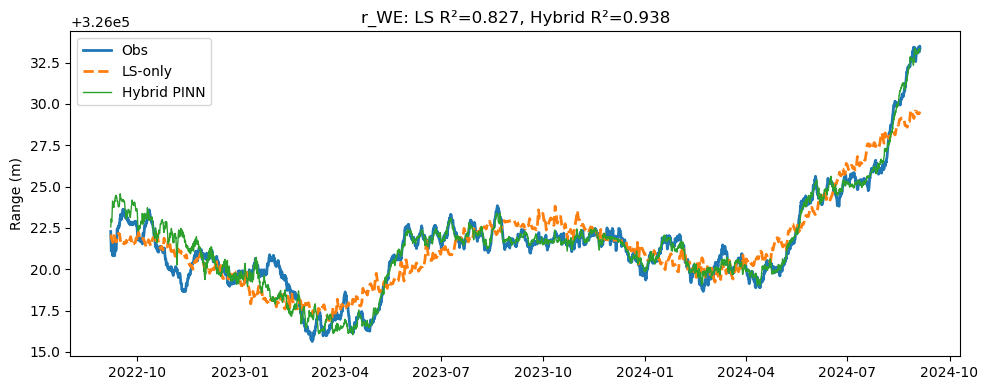

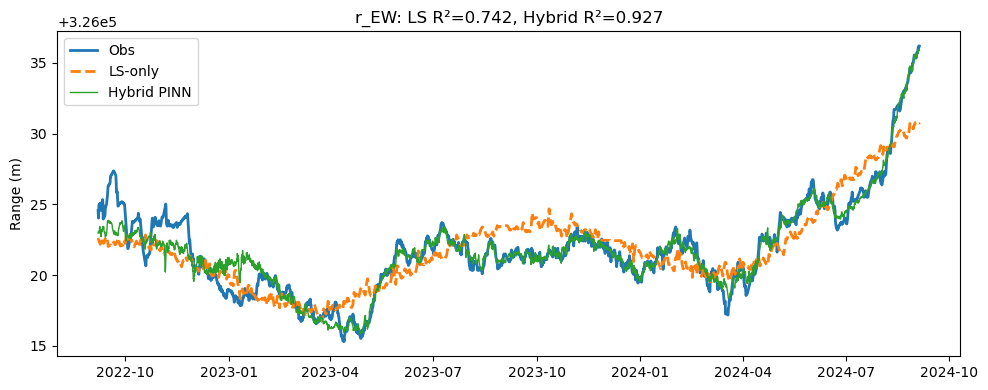

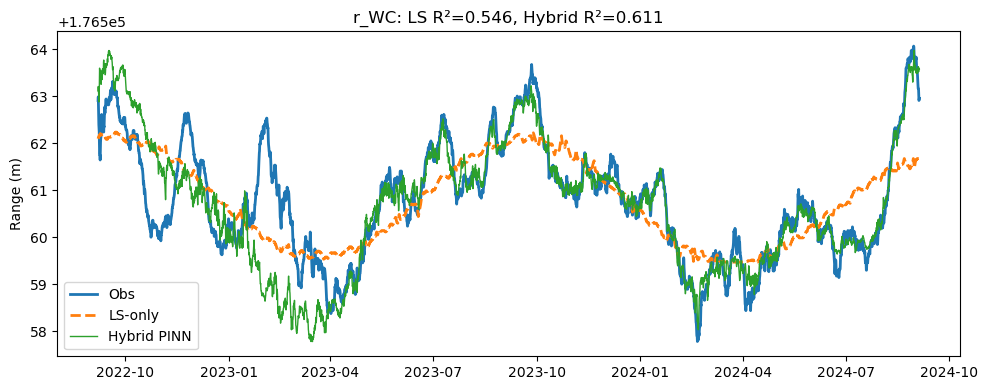

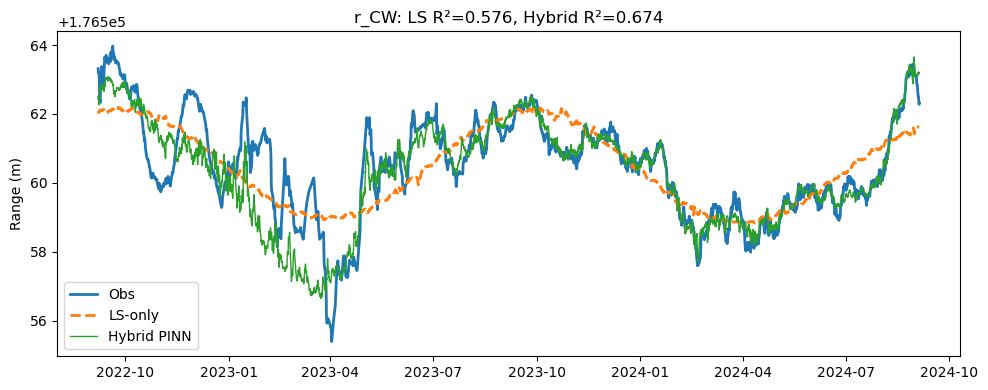

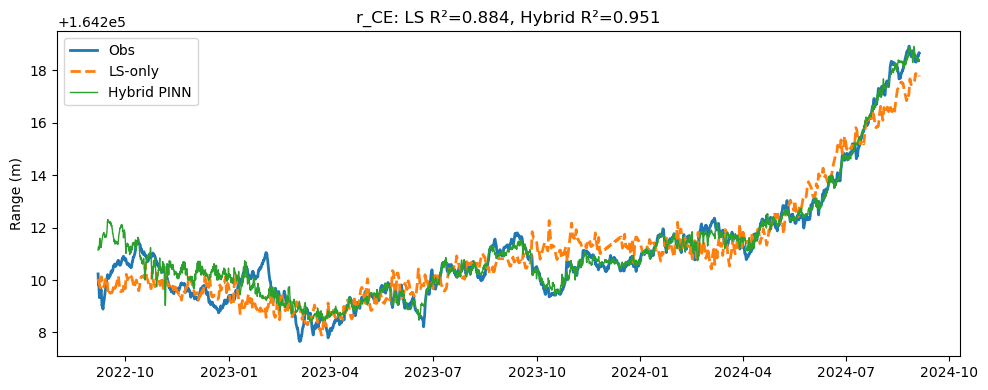

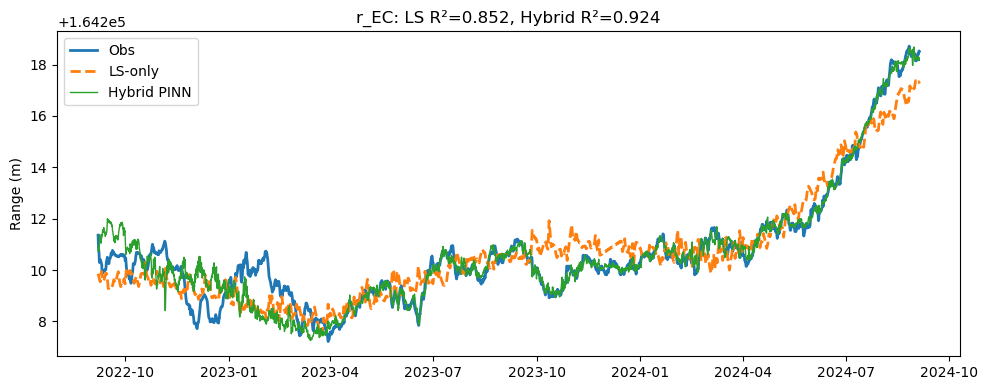

In [28]:
# 10) PLOT RESULTS
for i, name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(times_aligned, R_true_aligned[:,i],   label='Obs', lw=2)
    ax.plot(times_aligned, R_lin_aligned[:,i],    label='LS-only', ls='--', lw=2)
    ax.plot(times_aligned, R_pred_full[:,i],      label='Hybrid PINN', lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(R_true_aligned[:,i], R_lin_aligned[:,i]):.3f}, "
                 f"Hybrid R²={r2_score(R_true_aligned[:,i], R_pred_full[:,i]):.3f}")
    ax.legend(); ax.set_ylabel("Range (m)"); plt.show()



In [48]:
import os
# -----------------------------------------------------------------------------
# FORCE CPU PARALLELISM TO 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks, regularizers

# configure TensorFlow threading
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# =============================================================================
# ENHANCED HYBRID PINN: DROP OUT, L2 WEIGHT DECAY, LONGER LAGS
# – TRAIN ON LAST 70% – EVALUATE FULL SERIES
# =============================================================================

# 0) LOAD & FILTER
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022,9,7,tz='UTC')].reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],  'p2': df_var['p2'],  'p3': df_var['p3'],
    'r_WE': df_var['d1'],  'r_EW': df_var['d2'],  'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],  'r_WC': df_var['d5'],  'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASON + STANDARDIZED PRESSURES
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2 * np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()
sin_t, cos_t = df['sin1'].values, df['cos1'].values

# 2) LEAST-SQUARES BLOCKS
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE,*_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC,*_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin, r_EC_lin = A_CE @ x_CE, A_CE @ x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW,*_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC,*_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin, r_WC_lin = A_CW @ x_CW, A_CW @ x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW,*_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE,*_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin, r_WE_lin = A_EW @ x_EW, A_EW @ x_WE

R_lin        = np.column_stack([r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]).astype('float32')
R_obs        = df[Y_cols].values.astype('float32')
R_resid_full = (R_obs - R_lin).astype('float32')

# 3) FEATURE MATRIX + LONGER LAGS + LS FEATURES
lag_max = 7  # extend to 7 lags
df_feat = df[['p1','p2','p3','t_days','sin1','cos1']].copy()
for lag in range(1, lag_max+1):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)

for col, arr in zip(['r_WE_lin','r_EW_lin','r_WC_lin','r_CW_lin','r_CE_lin','r_EC_lin'],
                    [r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]):
    df_feat[col] = arr

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

idx             = df_feat.index.values
X_raw           = df_feat.values.astype('float32')
R_resid_aligned = R_resid_full[idx]
R_lin_aligned   = R_lin[idx]
R_true_aligned  = R_obs[idx]
times_aligned   = df['time'].values[idx]

# 4) SCALE & SPLIT LAST 70%
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_aligned)
Rs_s     = scaler_R.transform(R_resid_aligned)

N       = Xs.shape[0]
start   = int(0.30 * N)
X_train = Xs[start:]
Rs_train= Rs_s[start:]

# constants for un-scaling
mean_R  = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R = K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# indices for LS features
feat_cols = df_feat.columns.tolist()
i_CE, i_EC = feat_cols.index('r_CE_lin'), feat_cols.index('r_EC_lin')
i_CW, i_WC = feat_cols.index('r_CW_lin'), feat_cols.index('r_WC_lin')
i_WE, i_EW = feat_cols.index('r_WE_lin'), feat_cols.index('r_EW_lin')

# 5) BUILD 3-HEAD PINN WITH DROPOUT & L2
w_mse, w_sym, w_clo, w_hinge = 10.0, 0.5, 0.01, 5.0
l2 = 1e-5  # weight decay
d  = 0.3   # dropout rate

inp    = layers.Input(shape=(Xs.shape[1],))
shared = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(inp)
shared = layers.Dropout(d)(shared)
shared = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(shared)
shared = layers.Dropout(d)(shared)

east = layers.Lambda(lambda x: tf.gather(x, [i_CE, i_EC], axis=1))(inp)
west = layers.Lambda(lambda x: tf.gather(x, [i_CW, i_WC], axis=1))(inp)
mid  = layers.Lambda(lambda x: tf.gather(x, [i_WE, i_EW], axis=1))(inp)

def head_block(xf):
    xh = layers.Concatenate()([shared, xf])
    xh = layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(xh)
    xh = layers.Dropout(d)(xh)
    return layers.Dense(2, activation='linear')(xh)

r_CE_p, r_EC_p = tf.split(head_block(east), 2, axis=1)
r_CW_p, r_WC_p = tf.split(head_block(west), 2, axis=1)
r_WE_p, r_EW_p = tf.split(head_block(mid), 2, axis=1)

resid_out = layers.Concatenate()([
    r_WE_p, r_EW_p,
    r_WC_p, r_CW_p,
    r_CE_p, r_EC_p
])
model = Model(inp, resid_out)

# 6) LOSS WITH ABSOLUTE-ERROR HINGE
def loss_fn(r_true_s, r_pred_s):
    e_ls     = r_true_s * scale_R + mean_R
    pred_res = r_pred_s * scale_R + mean_R
    e_hybrid = e_ls - pred_res

    L_mse  = K.mean(K.square(r_true_s - r_pred_s))
    CE, EC = r_pred_s[:,4], r_pred_s[:,5]
    CW, WC = r_pred_s[:,3], r_pred_s[:,2]
    L_sym  = K.mean(K.square(CE - EC) + K.square(CW - WC))
    dCE  = CE[1:] - CE[:-1]; dCW = CW[1:] - CW[:-1]
    dEW  = r_pred_s[1:,1] - r_pred_s[:-1,1]
    L_clo= K.mean(K.square(dCE + dCW - dEW))

    delta  = K.abs(e_hybrid) - K.abs(e_ls)
    L_hinge= K.mean(K.maximum(delta, 0.0))

    return (w_mse * L_mse
          + w_sym * L_sym
          + w_clo * L_clo
          + w_hinge * L_hinge)

model.compile(optimizer='adam', loss=loss_fn)
es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)

# 7) TRAIN ON LAST 70%
model.fit(X_train, Rs_train, epochs=300, batch_size=len(X_train),
          callbacks=[es], verbose=1)

# 8) PREDICT & RECONSTRUCT FULL SERIES
Rs_pred_s   = model.predict(Xs)
Rs_pred     = scaler_R.inverse_transform(Rs_pred_s)
R_pred_full = R_lin_aligned + Rs_pred

# 9) EVALUATE & PRINT METRICS
print("LS-only metrics:")
for i, name in enumerate(Y_cols):
    r2_lin  = r2_score(R_true_aligned[:,i], R_lin_aligned[:,i])
    rmse_lin= mean_squared_error(R_true_aligned[:,i], R_lin_aligned[:,i], squared=False)
    print(f"{name}: R²={r2_lin:.3f}, RMSE={rmse_lin:.3f} m")

print("\nHybrid PINN (enhanced) metrics:")
for i, name in enumerate(Y_cols):
    r2_h   = r2_score(R_true_aligned[:,i], R_pred_full[:,i])
    rmse_h = mean_squared_error(R_true_aligned[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2_h:.3f}, RMSE={rmse_h:.3f} m")




Epoch 1/300
1/1 [==============================] - 1s 1s/step - loss: 15.9692
Epoch 2/300
1/1 [==============================] - 0s 9ms/step - loss: 14.8945
Epoch 3/300
1/1 [==============================] - 0s 8ms/step - loss: 13.8030
Epoch 4/300
1/1 [==============================] - 0s 8ms/step - loss: 12.9322
Epoch 5/300
1/1 [==============================] - 0s 8ms/step - loss: 12.6451
Epoch 6/300
1/1 [==============================] - 0s 8ms/step - loss: 12.1182
Epoch 7/300
1/1 [==============================] - 0s 8ms/step - loss: 11.7760
Epoch 8/300
1/1 [==============================] - 0s 8ms/step - loss: 11.3807
Epoch 9/300
1/1 [==============================] - 0s 8ms/step - loss: 11.1112
Epoch 10/300
1/1 [==============================] - 0s 8ms/step - loss: 10.8329
Epoch 11/300
1/1 [==============================] - 0s 7ms/step - loss: 10.8340
Epoch 12/300
1/1 [==============================] - 0s 8ms/step - loss: 10.4233
Epoch 13/300
1/1 [==============================] 

1/1 [==============================] - 0s 7ms/step - loss: 5.1896
Epoch 207/300
1/1 [==============================] - 0s 7ms/step - loss: 5.1635
Epoch 208/300
1/1 [==============================] - 0s 8ms/step - loss: 5.1158
Epoch 209/300
1/1 [==============================] - 0s 8ms/step - loss: 5.1127
Epoch 210/300
1/1 [==============================] - 0s 8ms/step - loss: 5.0516
Epoch 211/300
1/1 [==============================] - 0s 7ms/step - loss: 5.0852
Epoch 212/300
1/1 [==============================] - 0s 7ms/step - loss: 5.1074
Epoch 213/300
1/1 [==============================] - 0s 8ms/step - loss: 4.9941
Epoch 214/300
1/1 [==============================] - 0s 7ms/step - loss: 5.0523
Epoch 215/300
1/1 [==============================] - 0s 7ms/step - loss: 5.0802
Epoch 216/300
1/1 [==============================] - 0s 7ms/step - loss: 5.0044
Epoch 217/300
1/1 [==============================] - 0s 7ms/step - loss: 5.0265
Epoch 218/300
1/1 [==============================] - 0

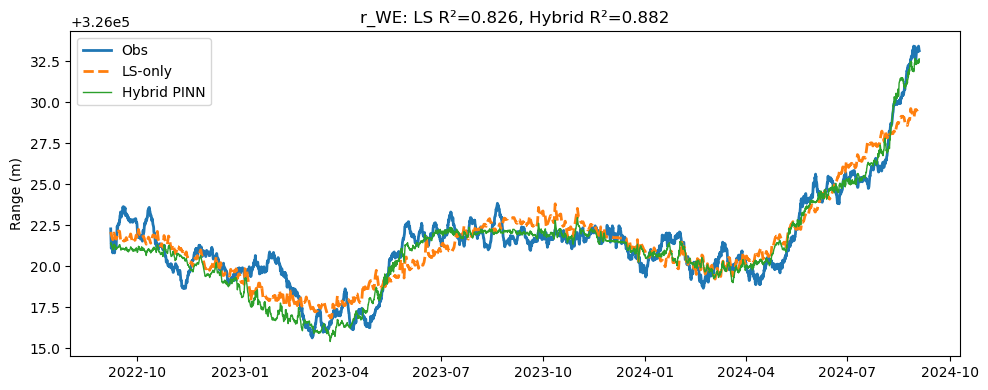

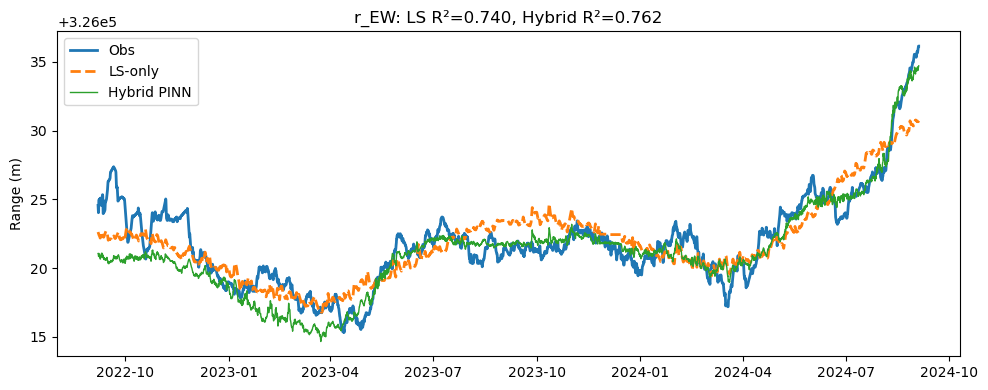

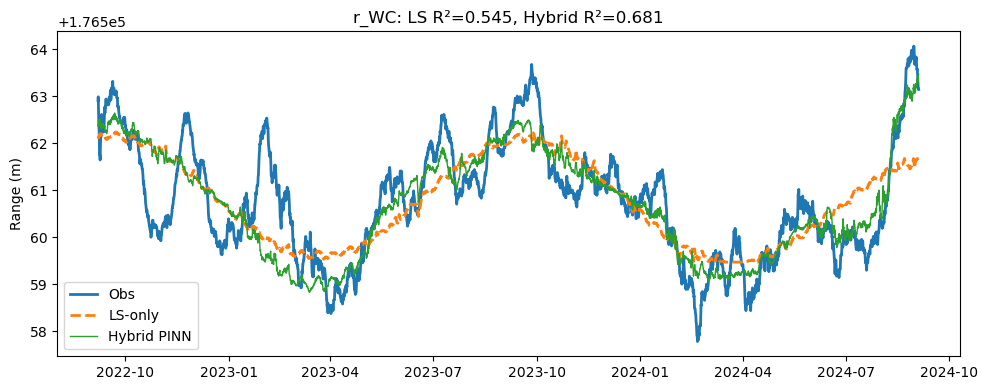

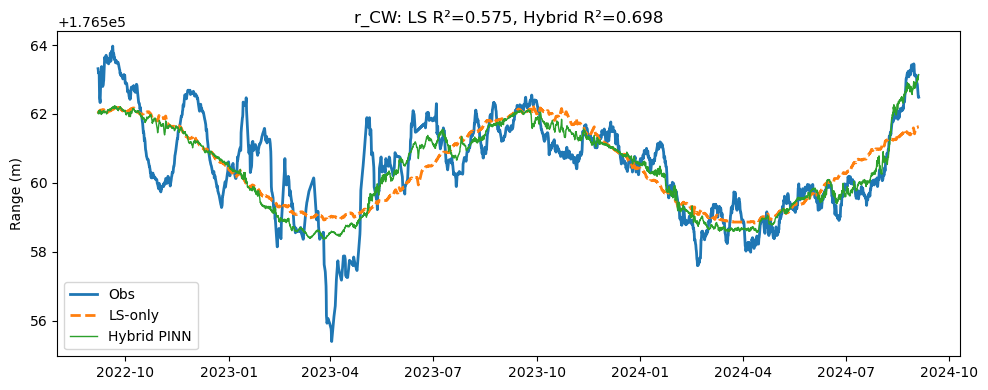

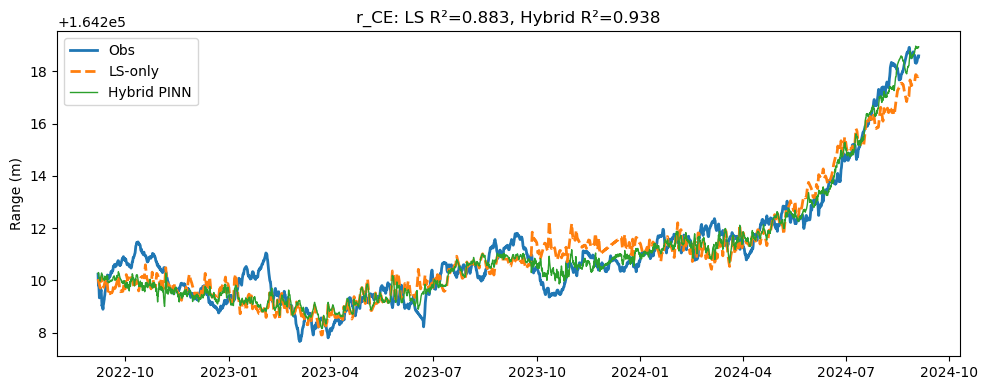

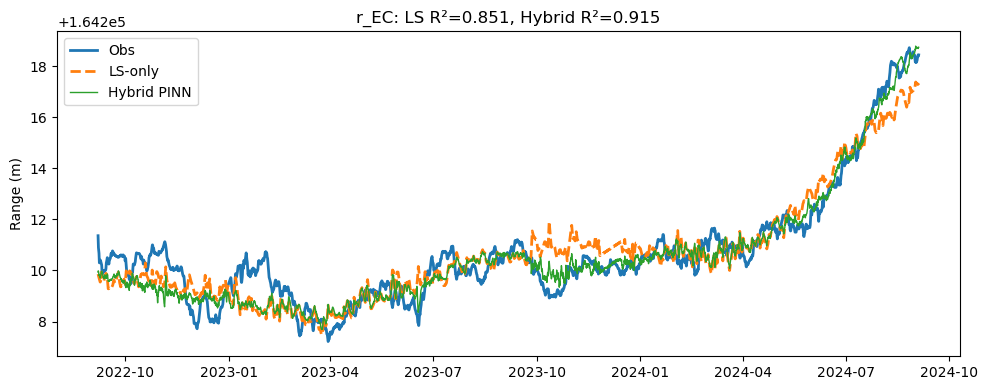

In [49]:
# 10) PLOT RESULTS
for i, name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(times_aligned, R_true_aligned[:,i],   label='Obs', lw=2)
    ax.plot(times_aligned, R_lin_aligned[:,i],    label='LS-only', ls='--', lw=2)
    ax.plot(times_aligned, R_pred_full[:,i],      label='Hybrid PINN', lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(R_true_aligned[:,i], R_lin_aligned[:,i]):.3f}, "
                 f"Hybrid R²={r2_score(R_true_aligned[:,i], R_pred_full[:,i]):.3f}")
    ax.legend(); ax.set_ylabel("Range (m)")
    plt.show()


In [43]:
import os
# -----------------------------------------------------------------------------
# FORCE CPU PARALLELISM TO 48 CORES
# -----------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"]      = "48"
os.environ["MKL_NUM_THREADS"]      = "48"
os.environ["OPENBLAS_NUM_THREADS"] = "48"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks, regularizers

# configure TensorFlow threading
tf.config.threading.set_intra_op_parallelism_threads(48)
tf.config.threading.set_inter_op_parallelism_threads(48)

# =============================================================================
# ENHANCED HYBRID PINN: DROP OUT, L2 WEIGHT DECAY, LONGER LAGS
# – TRAIN ON LAST 70% – EVALUATE FULL SERIES
# =============================================================================

# 0) LOAD & FILTER
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var[df_var['Record Time'] >= pd.Timestamp(2022,9,7,tz='UTC')].reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],  'p2': df_var['p2'],  'p3': df_var['p3'],
    'r_WE': df_var['d1'],  'r_EW': df_var['d2'],  'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],  'r_WC': df_var['d5'],  'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASON + STANDARDIZED PRESSURES
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2 * np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()
sin_t, cos_t = df['sin1'].values, df['cos1'].values

# 2) LEAST-SQUARES BLOCKS
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE,*_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC,*_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin, r_EC_lin = A_CE @ x_CE, A_CE @ x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW,*_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC,*_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin, r_WC_lin = A_CW @ x_CW, A_CW @ x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW,*_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE,*_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin, r_WE_lin = A_EW @ x_EW, A_EW @ x_WE

R_lin        = np.column_stack([r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]).astype('float32')
R_obs        = df[Y_cols].values.astype('float32')
R_resid_full = (R_obs - R_lin).astype('float32')

# 3) FEATURE MATRIX + LONGER LAGS + LS FEATURES
lag_max = 7  # extend to 7 lags
df_feat = df[['p1','p2','p3','t_days','sin1','cos1']].copy()
for lag in range(1, lag_max+1):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)

for col, arr in zip(['r_WE_lin','r_EW_lin','r_WC_lin','r_CW_lin','r_CE_lin','r_EC_lin'],
                    [r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]):
    df_feat[col] = arr

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

idx             = df_feat.index.values
X_raw           = df_feat.values.astype('float32')
R_resid_aligned = R_resid_full[idx]
R_lin_aligned   = R_lin[idx]
R_true_aligned  = R_obs[idx]
times_aligned   = df['time'].values[idx]

# 4) SCALE & SPLIT LAST 70%
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_aligned)
Rs_s     = scaler_R.transform(R_resid_aligned)

N       = Xs.shape[0]
start   = int(0.3 * N)
ends     = int(1 * N)
X_train = Xs[start:ends]
Rs_train= Rs_s[start:ends]

# constants for un-scaling
mean_R  = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R = K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# indices for LS features
feat_cols = df_feat.columns.tolist()
i_CE, i_EC = feat_cols.index('r_CE_lin'), feat_cols.index('r_EC_lin')
i_CW, i_WC = feat_cols.index('r_CW_lin'), feat_cols.index('r_WC_lin')
i_WE, i_EW = feat_cols.index('r_WE_lin'), feat_cols.index('r_EW_lin')

# 5) BUILD 3-HEAD PINN WITH DROPOUT & L2
w_mse, w_sym, w_clo, w_hinge = 10.0, 0.5, 0.01, 5.0
l2 = 1e-5  # weight decay
d  = 0.3   # dropout rate

inp    = layers.Input(shape=(Xs.shape[1],))
shared = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(inp)
shared = layers.Dropout(d)(shared)
shared = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(shared)
shared = layers.Dropout(d)(shared)

east = layers.Lambda(lambda x: tf.gather(x, [i_CE, i_EC], axis=1))(inp)
west = layers.Lambda(lambda x: tf.gather(x, [i_CW, i_WC], axis=1))(inp)
mid  = layers.Lambda(lambda x: tf.gather(x, [i_WE, i_EW], axis=1))(inp)

def head_block(xf):
    xh = layers.Concatenate()([shared, xf])
    xh = layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(xh)
    xh = layers.Dropout(d)(xh)
    return layers.Dense(2, activation='linear')(xh)

r_CE_p, r_EC_p = tf.split(head_block(east), 2, axis=1)
r_CW_p, r_WC_p = tf.split(head_block(west), 2, axis=1)
r_WE_p, r_EW_p = tf.split(head_block(mid), 2, axis=1)

resid_out = layers.Concatenate()([
    r_WE_p, r_EW_p,
    r_WC_p, r_CW_p,
    r_CE_p, r_EC_p
])
model = Model(inp, resid_out)

# 6) LOSS WITH ABSOLUTE-ERROR HINGE
def loss_fn(r_true_s, r_pred_s):
    e_ls     = r_true_s * scale_R + mean_R
    pred_res = r_pred_s * scale_R + mean_R
    e_hybrid = e_ls - pred_res

    L_mse  = K.mean(K.square(r_true_s - r_pred_s))
    CE, EC = r_pred_s[:,4], r_pred_s[:,5]
    CW, WC = r_pred_s[:,3], r_pred_s[:,2]
    L_sym  = K.mean(K.square(CE - EC) + K.square(CW - WC))
    dCE  = CE[1:] - CE[:-1]; dCW = CW[1:] - CW[:-1]
    dEW  = r_pred_s[1:,1] - r_pred_s[:-1,1]
    L_clo= K.mean(K.square(dCE + dCW - dEW))

    delta  = K.abs(e_hybrid) - K.abs(e_ls)
    L_hinge= K.mean(K.maximum(delta, 0.0))

    return (w_mse * L_mse
          + w_sym * L_sym
          + w_clo * L_clo
          + w_hinge * L_hinge)

model.compile(optimizer='adam', loss=loss_fn)
es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)

# 7) TRAIN ON LAST 70%
model.fit(X_train, Rs_train, epochs=300, batch_size=len(X_train),
          callbacks=[es], verbose=1)

# 8) PREDICT & RECONSTRUCT FULL SERIES
Rs_pred_s   = model.predict(Xs)
Rs_pred     = scaler_R.inverse_transform(Rs_pred_s)
R_pred_full = R_lin_aligned + Rs_pred

# 9) EVALUATE & PRINT METRICS
print("LS-only metrics:")
for i, name in enumerate(Y_cols):
    r2_lin  = r2_score(R_true_aligned[:,i], R_lin_aligned[:,i])
    rmse_lin= mean_squared_error(R_true_aligned[:,i], R_lin_aligned[:,i], squared=False)
    print(f"{name}: R²={r2_lin:.3f}, RMSE={rmse_lin:.3f} m")

print("\nHybrid PINN (enhanced) metrics:")
for i, name in enumerate(Y_cols):
    r2_h   = r2_score(R_true_aligned[:,i], R_pred_full[:,i])
    rmse_h = mean_squared_error(R_true_aligned[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2_h:.3f}, RMSE={rmse_h:.3f} m")



Epoch 1/300
1/1 [==============================] - 1s 1s/step - loss: 20.5085
Epoch 2/300
1/1 [==============================] - 0s 8ms/step - loss: 18.0611
Epoch 3/300
1/1 [==============================] - 0s 8ms/step - loss: 16.3067
Epoch 4/300
1/1 [==============================] - 0s 8ms/step - loss: 14.9840
Epoch 5/300
1/1 [==============================] - 0s 9ms/step - loss: 14.2776
Epoch 6/300
1/1 [==============================] - 0s 8ms/step - loss: 13.1008
Epoch 7/300
1/1 [==============================] - 0s 8ms/step - loss: 13.0397
Epoch 8/300
1/1 [==============================] - 0s 8ms/step - loss: 12.6718
Epoch 9/300
1/1 [==============================] - 0s 8ms/step - loss: 12.2551
Epoch 10/300
1/1 [==============================] - 0s 8ms/step - loss: 12.1155
Epoch 11/300
1/1 [==============================] - 0s 8ms/step - loss: 11.8050
Epoch 12/300
1/1 [==============================] - 0s 8ms/step - loss: 11.5942
Epoch 13/300
1/1 [==============================] 

1/1 [==============================] - 0s 8ms/step - loss: 5.5303
Epoch 207/300
1/1 [==============================] - 0s 8ms/step - loss: 5.4992
Epoch 208/300
1/1 [==============================] - 0s 7ms/step - loss: 5.5412
Epoch 209/300
1/1 [==============================] - 0s 8ms/step - loss: 5.4351
Epoch 210/300
1/1 [==============================] - 0s 7ms/step - loss: 5.4503
Epoch 211/300
1/1 [==============================] - 0s 7ms/step - loss: 5.4859
Epoch 212/300
1/1 [==============================] - 0s 8ms/step - loss: 5.4235
Epoch 213/300
1/1 [==============================] - 0s 8ms/step - loss: 5.3989
Epoch 214/300
1/1 [==============================] - 0s 7ms/step - loss: 5.5045
Epoch 215/300
1/1 [==============================] - 0s 7ms/step - loss: 5.4641
Epoch 216/300
1/1 [==============================] - 0s 7ms/step - loss: 5.4137
Epoch 217/300
1/1 [==============================] - 0s 8ms/step - loss: 5.3985
Epoch 218/300
1/1 [==============================] - 0

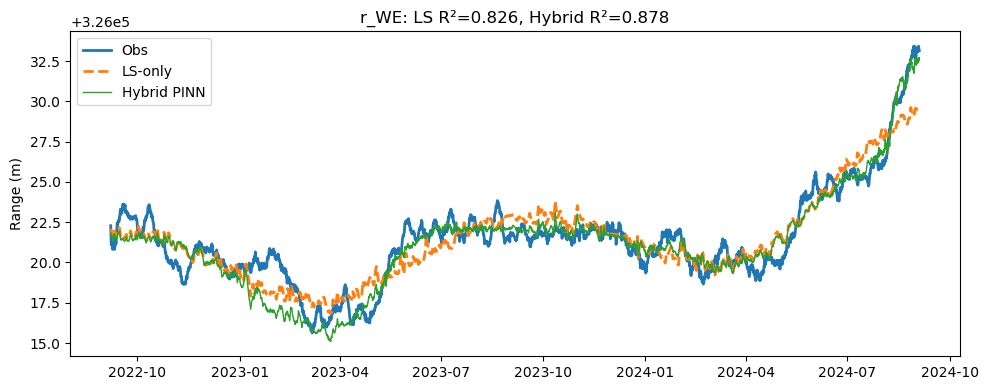

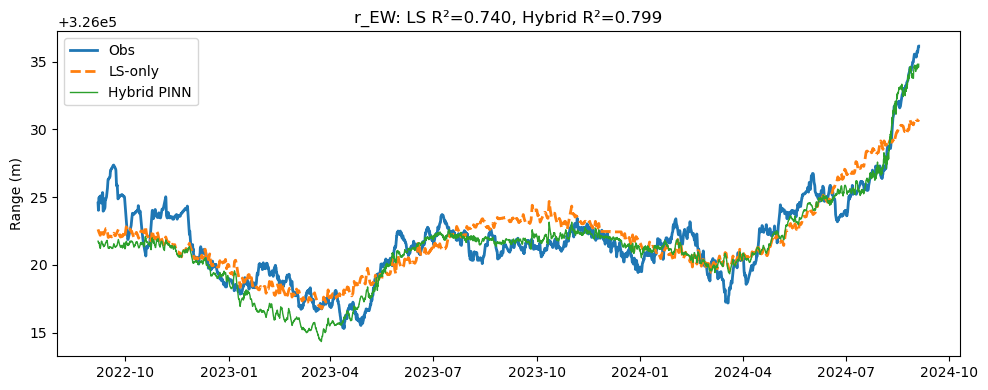

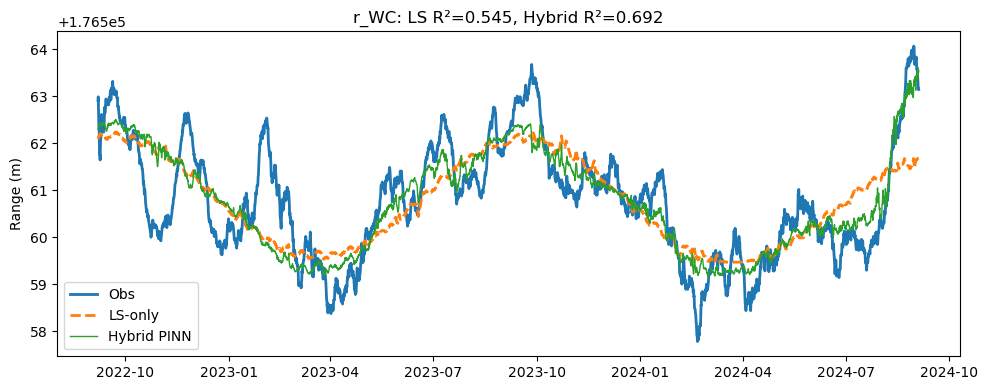

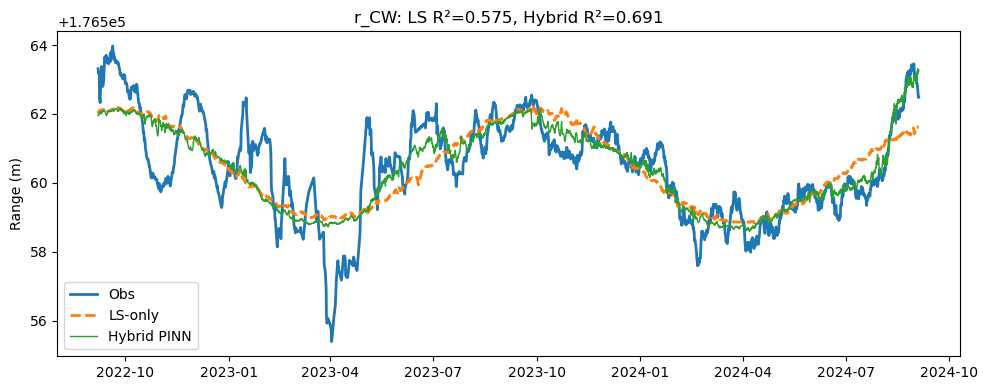

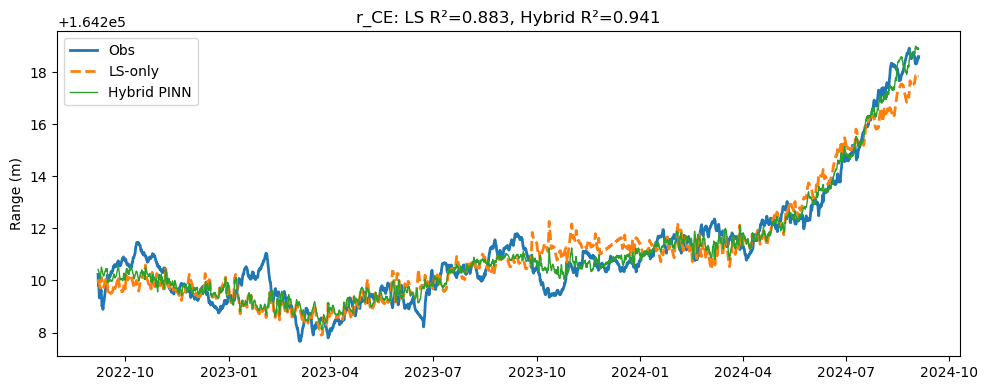

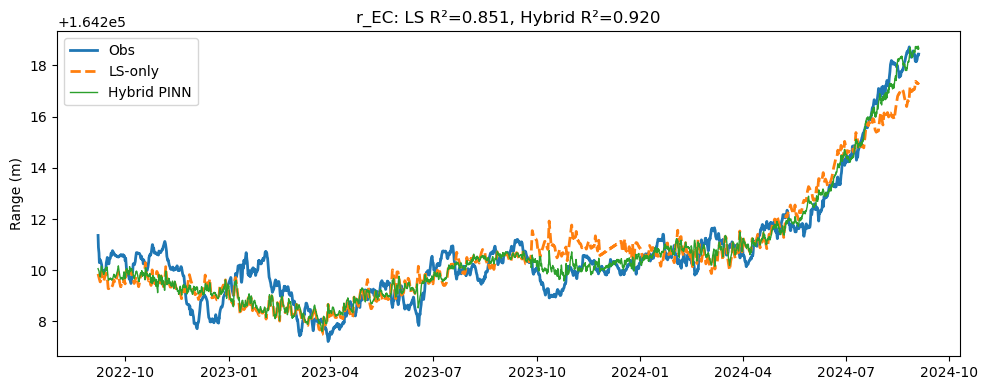

In [44]:
# 10) PLOT RESULTS
for i, name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(times_aligned, R_true_aligned[:,i],   label='Obs', lw=2)
    ax.plot(times_aligned, R_lin_aligned[:,i],    label='LS-only', ls='--', lw=2)
    ax.plot(times_aligned, R_pred_full[:,i],      label='Hybrid PINN', lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(R_true_aligned[:,i], R_lin_aligned[:,i]):.3f}, "
                 f"Hybrid R²={r2_score(R_true_aligned[:,i], R_pred_full[:,i]):.3f}")
    ax.legend(); ax.set_ylabel("Range (m)")
    plt.show()